# Preparing the dataset for PyTorch training

A lightweight notebook showcasing use of the AMBER dataset via Seisbench and via its own PyTorch dataset. 

In [1]:
from torch.utils.data import DataLoader
from amber import AMBER_DATA_COMPILED
from amber.utils import plot_batch

Below are the default filepaths for waveforms.hdf5 and metadata.csv files, if generated using amber.database.extract_data() (or via extract.py). We may also download pre-generated waveforms.hdf5 and metadata.csv files from [Zenodo](https://zenodo.org/records/18944111).

In [2]:
hdf5_path = AMBER_DATA_COMPILED / "waveforms.hdf5"
csv_path = AMBER_DATA_COMPILED / "metadata.csv"

### Seisbench

For the whole training pipeline using Seisbench, please see their [example PhaseNet training notebook](https://colab.research.google.com/github/seisbench/seisbench/blob/main/examples/03a_training_phasenet.ipynb).

In [3]:
import numpy as np
import seisbench.data as sbd
import seisbench.generate as sbg

In [4]:
dts = sbd.WaveformDataset(
    path=hdf5_path.parent,
    metadata=csv_path.name,
    waveforms=hdf5_path.name,
)
test_dataset = dts.get_split("test")
x, meta = test_dataset.get_sample(100)

print(x.shape)
print(meta.keys())

(3, 5156)
dict_keys(['index', 'trace_name', 'split', 'station', 'dataset', 'event_id', 'trace_sampling_rate_hz', 'trace_category', 'trace_start_time', 'trace_p_arrival_sample', 'trace_s_arrival_sample', 'trace_p_length', 'trace_s_length', 'trace_component_order', 'dimension_order', 'trace_p2_arrival_sample', 'trace_s2_arrival_sample', 'trace_p3_arrival_sample', 'trace_s3_arrival_sample', 'trace_p4_arrival_sample', 'trace_s4_arrival_sample', 'trace_chunk', 'trace_source_sampling_rate_hz', 'trace_npts'])


In [5]:
phase_dict = {
    "trace_p_arrival_sample": "P",
    "trace_s_arrival_sample": "S",
}

test_generator = sbg.GenericGenerator(test_dataset)
test_generator.add_augmentations([
    sbg.WindowAroundSample(
        list(phase_dict.keys()),
        samples_before=3000,
        windowlen=6000,
        selection="random",
        strategy="variable",
    ),
    sbg.RandomWindow(windowlen=3001, strategy="pad"),
    sbg.ChangeDtype(np.float32),
    sbg.ProbabilisticLabeller(
        label_columns=phase_dict, sigma=30, dim=0
    ),
    sbg.ChangeDtype(np.float32, key="y"),
])

(5, 3, 3001) (5, 3, 3001)


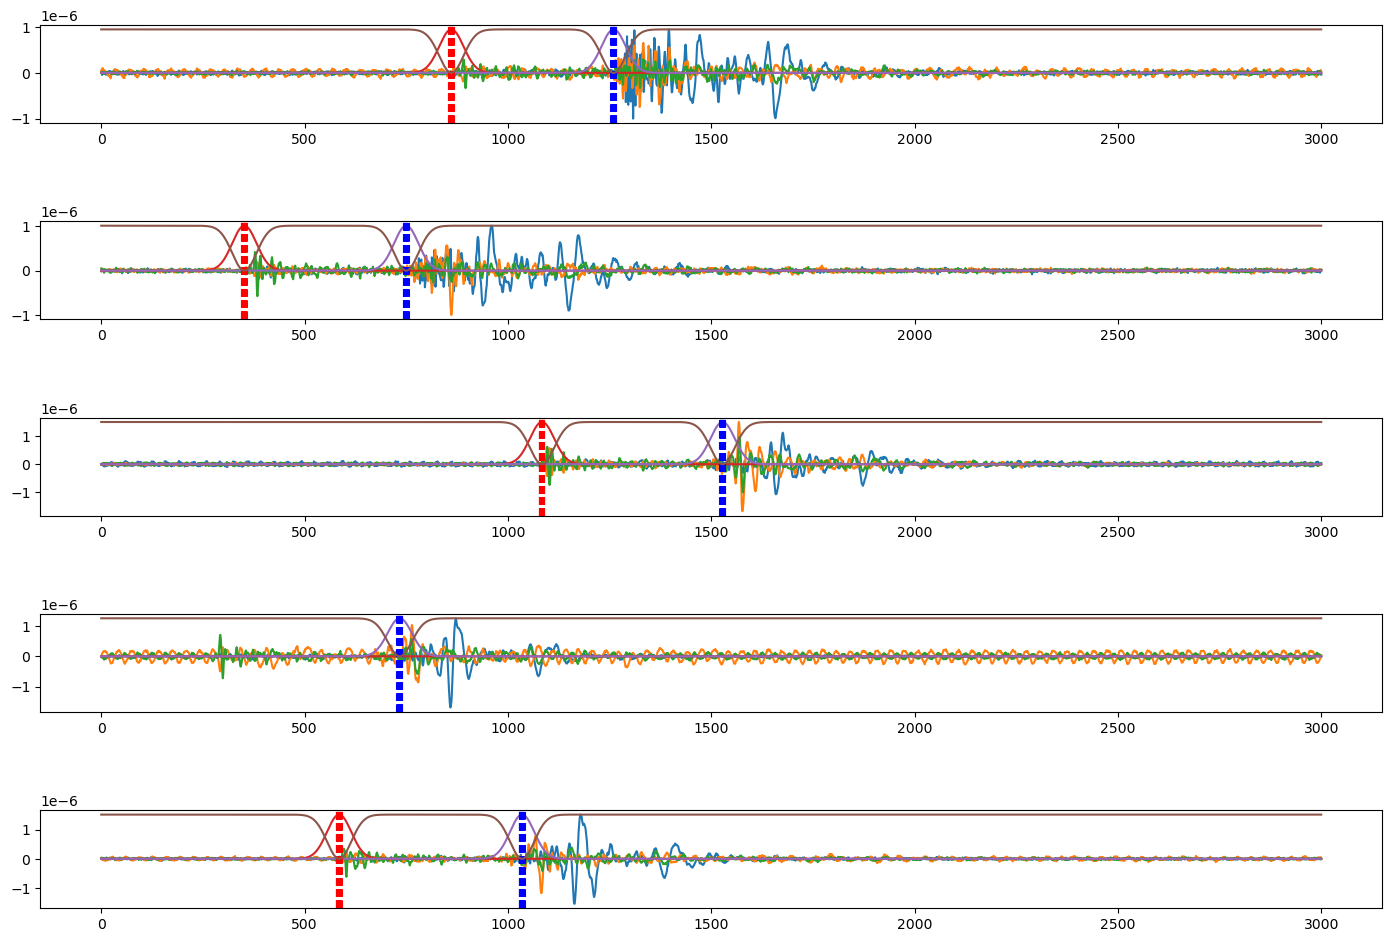

In [6]:
test_dataloader = DataLoader(test_generator, batch_size=5, shuffle=False, drop_last=True)

plot_batch(dataloader=test_dataloader, batch_idx=0)

### AMBER

In [7]:
from amber.dataloaders import AMBER, DatasetConfig
from amber.Augmentations import load_augmentations, AugmentationConfig
from amber.Labeller import create_labeller, LabellerConfig

AMBER uses a registry system to enable dynamically loading augmentations and labeller by name. We may check the registry for registered augmentations:

In [8]:
from amber.registry import augmentation_registry

for name, cls in augmentation_registry._registry.items():
    print(name)
    print("  scope:", cls.scope)
    print("  required:", cls.required_params)
    print("  optional:", cls.optional_params)
    print()

random_phase_rotation
  scope: windowed
  required: []
  optional: {'augment_chance': 0.4, 'log_level': None}

random_noise
  scope: windowed
  required: ['same_dataset', 'same_stations']
  optional: {'noise_amp_min': 0.5, 'noise_amp_max': 1.0}

overlap_events
  scope: windowed
  required: ['same_dataset', 'same_stations']
  optional: {'event_amp_min': 1, 'event_amp_max': 2}

resample
  scope: raw
  required: []
  optional: {'samplerate': 4000, 'windowlength': 4000}

random_rotation
  scope: windowed
  required: ['mode']
  optional: {'augment_chance': 0.4, 'log_level': None}

random_dropout
  scope: windowed
  required: ['dropout_nsta']
  optional: {'all_dropout_chance': 0.5}

random_resampling
  scope: raw
  required: []
  optional: {'maxrange': 1.5, 'minrange': 0.9}

transpose
  scope: windowed
  required: []
  optional: {'augment_chance': 0.4, 'log_level': None}

random_flip
  scope: windowed
  required: []
  optional: {'augment_chance': 0.4, 'log_level': None}

random_syn_noise
  s

and for labellers:

In [9]:
from amber.registry import labeller_registry

for name, cls in labeller_registry._registry.items():
    print(name)
    print("  required:", cls.required_params)
    print("  optional:", cls.optional_params)
    print()

tapered_labeller
  required: ['dropoff', 'windowlength']
  optional: {'log_level': None}



We would need to configure the dataset, augmentation, and labeller when using AMBER. Augmentation and labeller parameters are provided for illustration only and may be adjusted depending on the dataset and model requirements.

In [10]:
# PyTorch dataset config
dtscfg = DatasetConfig(
    windowlength = 4000,    # Target window length for model input
    nstation = 8,    # Target number of stations for model input
    normalisation = "stationwise",    # Choice of trace normalisation (stationwise, tracewise, eventwise)
    sequentialstations = True,    # Only extract sequential stations (vs random subset)
    fullphasecoverage = False    # Extract event-centric windows with both p and s (vs phase-centric)
)

# Augmentation config (depends on specified augmentations)
augcfg = AugmentationConfig(
    augmentations=[
        # Resample all waveforms to 4000 Hz (sampling rate may be auto-adjusted for shorter waveforms)
        {
            "type": "resample",     # name of the augmentation registered in registry
            "params": {"samplingrate": 4000, "windowlength": 4000}    # parameters required for the augmentation
        },
        
        # Randomly applied data augmentation
        {"type": "random_flip", "params": {"augment_chance": 0.5}},
    ]
)
# Initiate the list of augmentations to apply from config
augmentations = load_augmentations(augcfg)

# Labeller config (depends on the specified labeller)
lblcfg = LabellerConfig(
    dynamic_params={
        "dropoff":50,
        "windowlength":4000
    }
)
# Initiate the labeller object from the labeller config
labeller = create_labeller(
    "tapered_labeller",    # name of the labeller (from registry)
    lblcfg
)


# Load the augmentation list, labeller, and dataset config into AMBER
test_dataset = AMBER(
    dtscfg, 
    hdf5_path,    # filepath to the hdf5 file containing the traces
    csv_path,    # filepath to the metadata csv file
    labeller, 
    augmentations, 
    "test"    # chosen data split category ("all" for all data)
)

We can then wrap the dataset in a PyTorch DataLoader to prepare batches for model training:

(5, 8, 3, 4000) (5, 8, 3, 4000)


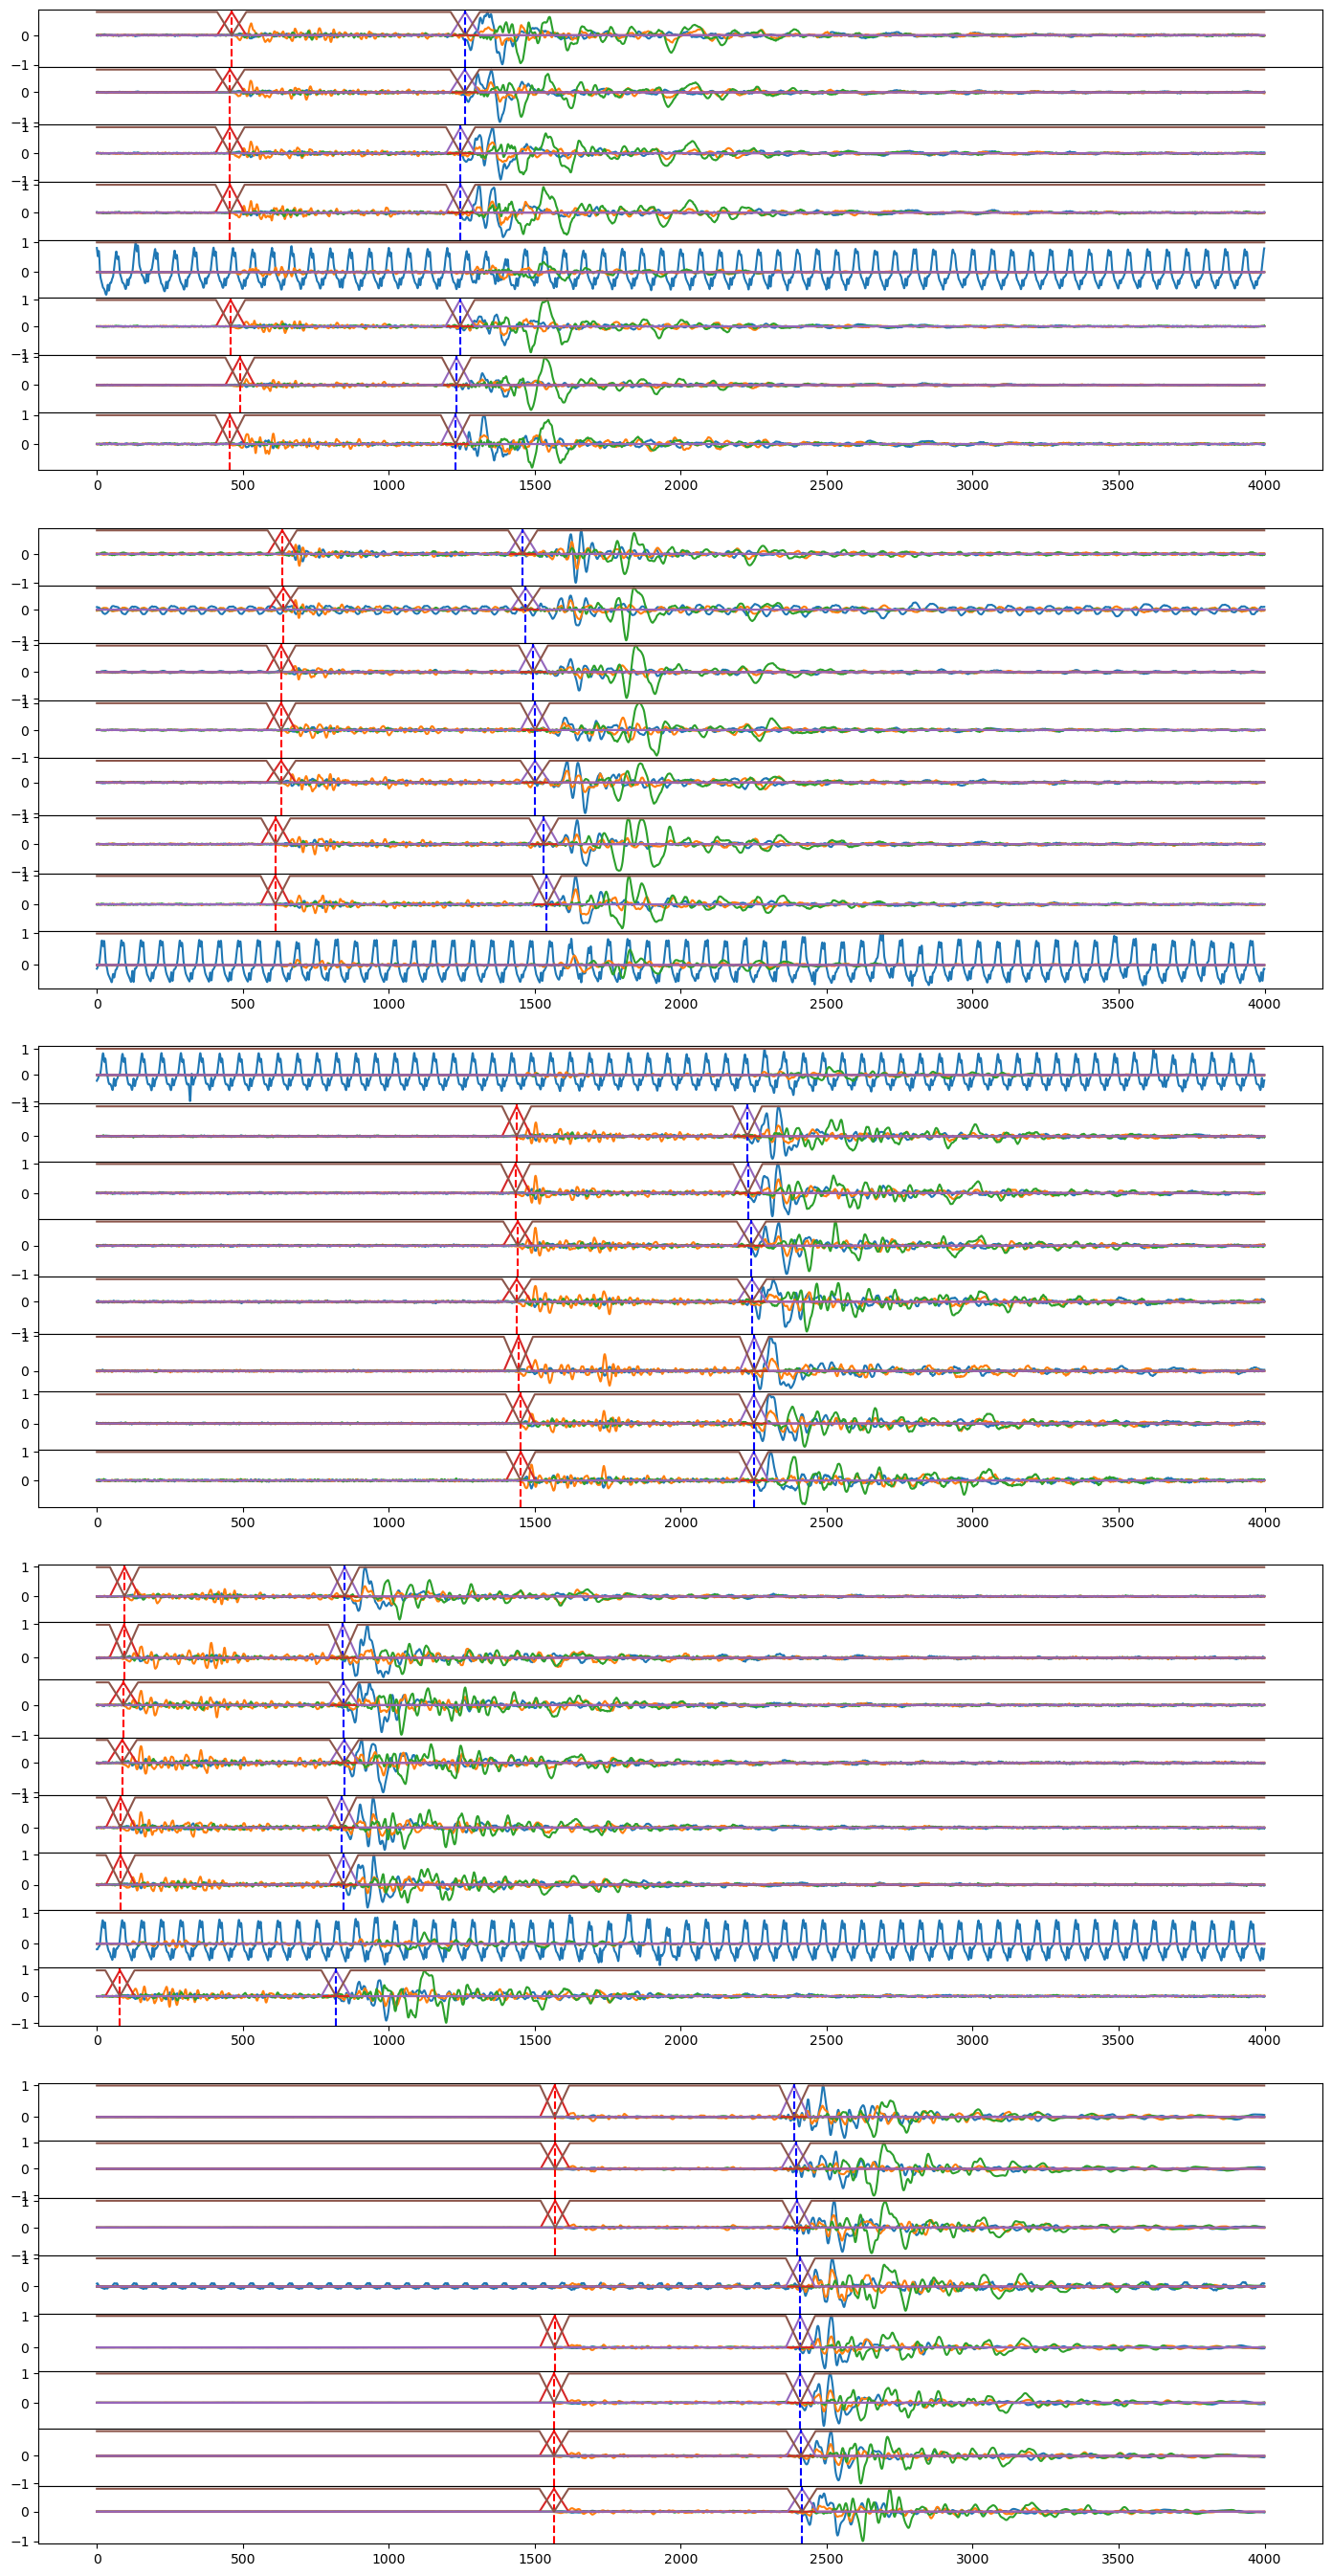

In [11]:
test_dataloader = DataLoader(test_dataset, batch_size=5, shuffle=False, drop_last=True)

plot_batch(dataloader=test_dataloader, batch_idx=0)